In [14]:
import numpy as np
import matplotlib.pyplot as plt
from dl import authClient as ac, queryClient as qc
import pandas as pd
from io import StringIO


This pipeline only selects single stars and ignores binaries. Dal Tio et al. (2022) has an in depth discussion on this topic and suggests something slightly different. For a first pass, this seems fine.

In [52]:
res = qc.query(sql=query, format='pandas')

In [75]:
def generate_query(ra0, dec0, radius):
    query = f"""
    SELECT l.ra, l.dec, l.pmracosd, l.pmdec, l.vrad,
           l.g_bpmag, l.g_rpmag, l.gaia_gmag,
           l.gmag, l.rmag, l.imag, l.zmag, l.ymag, l.umag,
           l.label, l.m_h, l.m_ini, l.mass, l.mu0, l.gc
    FROM lsst_sim.simdr2 AS l
    WHERE q3c_radial_query(l.ra, l.dec, {ra0}, {dec0}, {radius})
    """
    return query

In [87]:
gc_centers = [(15.0, -30.0)] # List of globular cluster centers (ra, dec)
radius = 5 # Radius in degrees

for gc_center in gc_centers:
    ra0, dec0 = gc_center
    query = generate_query(ra0, dec0, radius)
    df = qc.query(sql=query, fmt='pandas')

In [88]:
df

,ra,dec,pmracosd,pmdec,vrad,g_bpmag,g_rpmag,gaia_gmag,gmag,rmag,imag,zmag,ymag,umag,label,m_h,m_ini,mass,mu0,gc
0,13.883053,-34.908725,1.39,-3.01,72.25,24.824,22.517,23.571,25.408,23.953,22.961,22.476,22.260,28.361,1,-0.66,0.20420,0.203,12.50,2
1,13.898709,-34.910261,1.10,-1.53,130.57,26.306,25.131,25.776,26.489,25.803,25.514,25.383,25.317,27.946,1,-1.88,0.50528,0.505,18.40,3
2,13.902922,-34.907810,2.67,-1.21,31.43,27.854,25.646,26.670,28.458,26.973,26.079,25.640,25.441,31.419,1,-0.88,0.18093,0.179,15.50,3
3,13.897652,-34.906272,1.24,-0.63,21.79,26.928,25.270,26.109,27.327,26.171,25.670,25.428,25.296,29.716,1,-0.84,0.47121,0.470,17.80,3
4,13.892923,-34.905844,4.45,-4.84,-12.57,24.135,21.839,22.889,24.740,23.255,22.280,21.803,21.592,27.726,1,-0.78,0.18084,0.179,11.60,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1570898,17.414002,-25.480906,0.18,-0.18,32.01,25.399,24.615,25.071,25.476,25.093,24.983,24.964,24.956,26.581,1,-0.37,0.86922,0.868,20.90,3
1570899,17.417901,-25.481904,1.79,-5.57,-153.63,27.749,25.734,26.697,28.333,26.874,26.151,25.797,25.622,31.186,1,-1.24,0.16571,0.165,15.65,3
1570900,17.355438,-25.463514,-0.51,-1.29,90.61,25.267,24.402,24.905,25.372,24.937,24.773,24.717,24.698,26.334,1,-1.62,0.64668,0.646,19.05,3
1570901,17.357257,-25.460693,0.28,-0.45,25.58,27.264,26.253,26.822,27.399,26.843,26.629,26.543,26.500,28.669,1,-1.26,0.60856,0.608,20.45,3


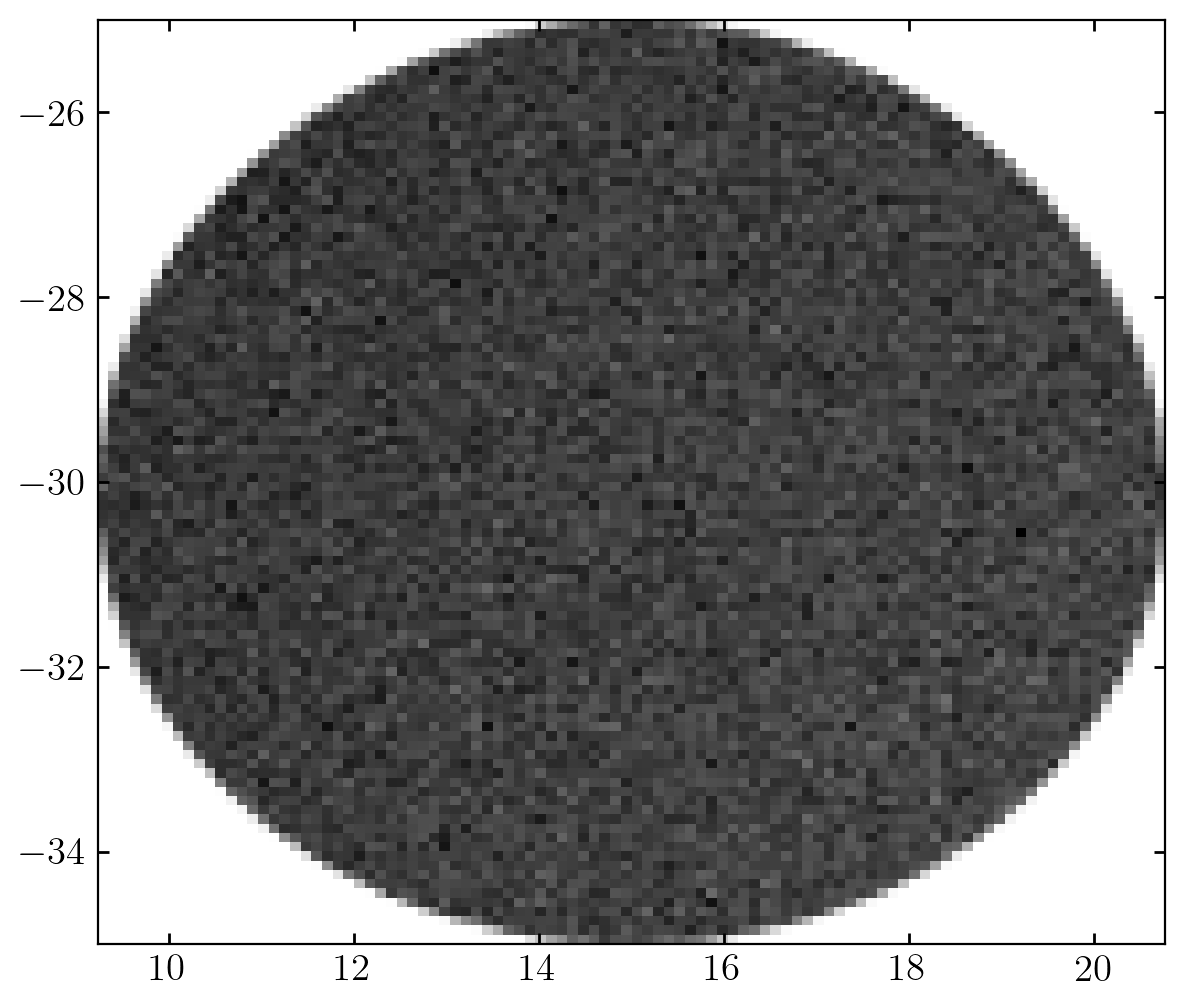

In [89]:
plt.hist2d(df.ra,df.dec, bins=100, cmap='gray_r')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()